In [1]:
import pandas as pd
from pathlib import Path

dataset_path = Path("../dataset/raw/healthcare_dataset.csv")

df = pd.read_csv(dataset_path)

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (55500, 15)

Columns:
['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']

First 5 Rows:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


Missing Values and Duplicates

In [2]:
# Missing values
print("Missing Values:")
display(df.isnull().sum())

# Duplicate records
print("Duplicate Rows:", df.duplicated().sum())

# Data types
print("\nData Types:")
display(df.dtypes)

Missing Values:


Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

Duplicate Rows: 534

Data Types:


Name                      str
Age                     int64
Gender                    str
Blood Type                str
Medical Condition         str
Date of Admission         str
Doctor                    str
Hospital                  str
Insurance Provider        str
Billing Amount        float64
Room Number             int64
Admission Type            str
Discharge Date            str
Medication                str
Test Results              str
dtype: object

Check Categories

In [3]:
categorical_columns = [
    "Gender",
    "Blood Type",
    "Medical Condition",
    "Insurance Provider",
    "Admission Type",
    "Medication",
    "Test Results"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


Gender:
Gender
Male      27774
Female    27726
Name: count, dtype: int64

Blood Type:
Blood Type
A-     6969
A+     6956
AB+    6947
AB-    6945
B+     6945
B-     6944
O+     6917
O-     6877
Name: count, dtype: int64

Medical Condition:
Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64

Insurance Provider:
Insurance Provider
Cigna               11249
Medicare            11154
UnitedHealthcare    11125
Blue Cross          11059
Aetna               10913
Name: count, dtype: int64

Admission Type:
Admission Type
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64

Medication:
Medication
Lipitor        11140
Ibuprofen      11127
Aspirin        11094
Paracetamol    11071
Penicillin     11068
Name: count, dtype: int64

Test Results:
Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64


Convert Dates and Calculate Length of Stay

In [4]:
df["Date of Admission"] = pd.to_datetime(
    df["Date of Admission"],
    errors="coerce"
)

df["Discharge Date"] = pd.to_datetime(
    df["Discharge Date"],
    errors="coerce"
)

df["Length of Stay"] = (
    df["Discharge Date"] - df["Date of Admission"]
).dt.days

display(df[[
    "Date of Admission",
    "Discharge Date",
    "Length of Stay"
]].head())

print(df["Length of Stay"].describe())

,Date of Admission,Discharge Date,Length of Stay
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


count    55500.000000
mean        15.509009
std          8.659600
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Length of Stay, dtype: float64


Visualize Medical Conditions

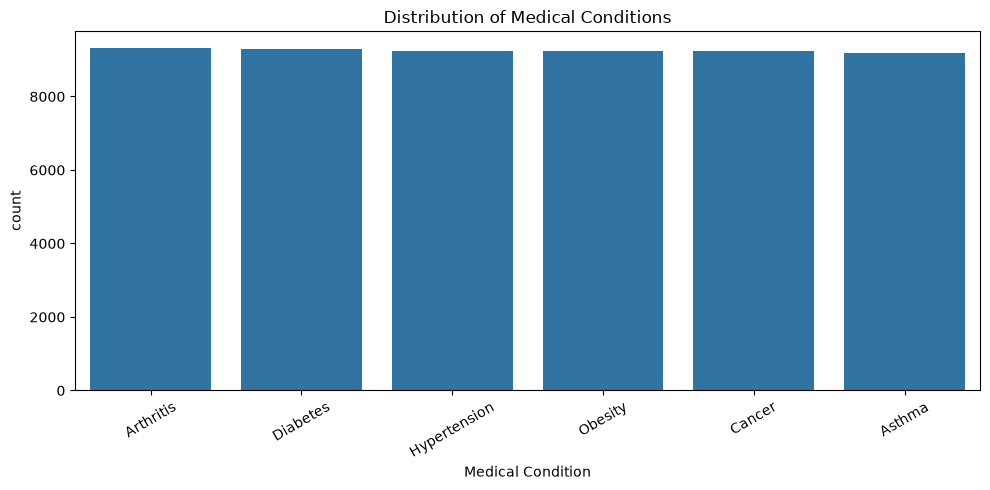

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Medical Condition",
    order=df["Medical Condition"].value_counts().index
)

plt.title("Distribution of Medical Conditions")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Investigate Duplicate Rows

In [7]:
# Investigate duplicate records
duplicate_count = df.duplicated().sum()

print("Total duplicate rows:", duplicate_count)

if duplicate_count > 0:
    print("\nSample duplicate records:")
    display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head(10))
else:
    print("No duplicate records found.")

# Check whether duplicate rows are exact duplicates across all columns.
print("\nDuplicate investigation completed.")


Total duplicate rows: 534

Sample duplicate records:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
42407,ABIgaIL YOung,41,Female,O+,Hypertension,2022-12-15,Edward Kramer,Moore-Mcdaniel,UnitedHealthcare,1983.568297,192,Elective,2023-01-13,Ibuprofen,Normal,29
54285,ABIgaIL YOung,41,Female,O+,Hypertension,2022-12-15,Edward Kramer,Moore-Mcdaniel,UnitedHealthcare,1983.568297,192,Elective,2023-01-13,Ibuprofen,Normal,29
26025,ALIcia taYLoR,78,Male,O+,Asthma,2022-09-18,Dawn Burton,Wright LLC,Aetna,31465.274979,149,Elective,2022-10-15,Aspirin,Inconclusive,27
53104,ALIcia taYLoR,78,Male,O+,Asthma,2022-09-18,Dawn Burton,Wright LLC,Aetna,31465.274979,149,Elective,2022-10-15,Aspirin,Inconclusive,27
42323,AMy GREEN,79,Female,B+,Obesity,2021-03-30,Brett Johnson,Taylor-Williamson,UnitedHealthcare,23402.358491,249,Elective,2021-04-27,Penicillin,Abnormal,28
50151,AMy GREEN,79,Female,B+,Obesity,2021-03-30,Brett Johnson,Taylor-Williamson,UnitedHealthcare,23402.358491,249,Elective,2021-04-27,Penicillin,Abnormal,28
21675,ANDREA HansEN,61,Male,O+,Cancer,2021-07-02,Alisha Flores,LLC Clark,Cigna,40026.763948,254,Elective,2021-07-22,Paracetamol,Normal,20
51695,ANDREA HansEN,61,Male,O+,Cancer,2021-07-02,Alisha Flores,LLC Clark,Cigna,40026.763948,254,Elective,2021-07-22,Paracetamol,Normal,20
36207,ANDrEA fREnCH,73,Male,A-,Arthritis,2021-02-08,Danny Oconnor,"Taylor Small, Lin and",UnitedHealthcare,9981.590235,323,Elective,2021-02-24,Ibuprofen,Inconclusive,16
51916,ANDrEA fREnCH,73,Male,A-,Arthritis,2021-02-08,Danny Oconnor,"Taylor Small, Lin and",UnitedHealthcare,9981.590235,323,Elective,2021-02-24,Ibuprofen,Inconclusive,16



Duplicate investigation completed.


## Validate the Dataset

Check for invalid ages, negative billing amounts, invalid length of stay, and inconsistent admission/discharge dates.

In [8]:
# Check invalid ages
print("Invalid ages:")
display(df[(df["Age"] < 0) | (df["Age"] > 120)])

# Check negative billing amounts
print("Negative billing amounts:")
display(df[df["Billing Amount"] < 0])

# Check invalid length of stay
print("Invalid length of stay:")
display(df[df["Length of Stay"] < 0])

# Check invalid admission/discharge dates
print("Invalid admission/discharge dates:")
display(df[df["Date of Admission"] > df["Discharge Date"]])


Invalid ages:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay


Negative billing amounts:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
132,ashLEy ERIcKSoN,32,Female,AB-,Cancer,2019-11-05,Gerald Hooper,"and Johnson Moore, Branch",Aetna,-502.507813,376,Urgent,2019-11-23,Penicillin,Normal,18
799,CHRisTOPHer wEiss,49,Female,AB-,Asthma,2023-02-16,Kelly Thompson,Hunter-Hughes,Aetna,-1018.245371,204,Elective,2023-03-09,Penicillin,Inconclusive,21
1018,AsHley WaRnER,60,Male,A+,Hypertension,2021-12-21,Andrea Bentley,"and Wagner, Lee Klein",Aetna,-306.364925,426,Elective,2022-01-11,Ibuprofen,Normal,21
1421,JAY galloWaY,74,Female,O+,Asthma,2021-01-20,Debra Everett,Group Peters,Blue Cross,-109.097122,381,Emergency,2021-02-09,Ibuprofen,Abnormal,20
2103,josHUa wilLIamSon,72,Female,B-,Diabetes,2021-03-21,Wendy Ramos,"and Huff Reeves, Dennis",Blue Cross,-576.727907,369,Urgent,2021-04-17,Aspirin,Abnormal,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52894,JosEPh cOx,23,Male,AB-,Diabetes,2019-10-13,Peter Smith,Inc Ward,Blue Cross,-353.865186,271,Elective,2019-10-25,Lipitor,Inconclusive,12
53204,AsHley WaRnER,55,Male,A+,Hypertension,2021-12-21,Andrea Bentley,"and Wagner, Lee Klein",Aetna,-306.364925,426,Elective,2022-01-11,Ibuprofen,Normal,21
53232,dAnIel dRaKe,68,Female,B+,Hypertension,2020-04-24,Brett Ray,Carr Ltd,Aetna,-591.917419,426,Elective,2020-04-26,Lipitor,Abnormal,2
54136,DR. micHaEl MckAy,64,Male,O+,Cancer,2019-05-31,Dawn Navarro,"Mcconnell and Rios, Clark",UnitedHealthcare,-199.663795,122,Urgent,2019-06-12,Ibuprofen,Abnormal,12


Invalid length of stay:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay


Invalid admission/discharge dates:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay


Analyze Medical Conditions

In [10]:
condition_summary = (
    df["Medical Condition"]
    .value_counts()
    .rename_axis("Medical Condition")
    .reset_index(name="Patient Count")
)

condition_summary["Percentage"] = (
    condition_summary["Patient Count"] / len(df) * 100
).round(2)

display(condition_summary)

,Medical Condition,Patient Count,Percentage
0,Arthritis,9308,16.77
1,Diabetes,9304,16.76
2,Hypertension,9245,16.66
3,Obesity,9231,16.63
4,Cancer,9227,16.63
5,Asthma,9185,16.55
